# Evaluating Causal Inference Methods - Estimating Job Training Effects on Earnings

Can the methods of causal inference recover the causal effect identified via a randomised control trial? This notebook explores whether this is the case by replicating and extending the LaLonde (1986) paper. This paper explored whether econometric methods could recover effect of job training on future earnings discovered in a randomised controlled trial. Such exercises, where the true causal effect is known, are very useful for the practicioners of causal inference as they allow us to test our methods on real data. Much of the evaluation of causal inference methods is ran on synthetic datasets with a knows causal DAG.

Before any analysis it will be beneficial to state some notation and terminology here, and to show the central problem causal inference tries to solve. In this case study we want to know if job training has an effect on future earnings. Job training is the treatment and future earnings the response. We denote each individual as $Y_{i}$, furthermore, the future earnings of the $i^{ith}$ under the treatment is denoted as $Y_{i}^{1}$ and without the treatment $Y_{i}^{0}$. However, the core problem of causal inference is for each individual we only ever observe one of the two outcomes, they either had the treatment or they didn't. Therefore, we never observe all the data in the above equations and this means we must try to estimate. The potential outcomes are related to the observed outcomes via the treatment identifier $W_{i}$. That is,

$$
Y_{i} = W_{i}Y_{i}^{1} + (1 - W_{i})Y_{i}^{0}
$$

Notice $Y_{i}$ does not have superscript, this means it was observed. Furthermore, notice how the observed outcome is related to the potential outcomes. $W_{i}$ takes on a value of $1$ when the individual was assigned to the treatment and then the observed outcome is equal to $Y_{i}^{1}$ whereas when the individual is not assigned to the treatment and $W_{i}$ is $0$ then the observed outcome is $Y_{i}^{0}$.

In this case in particular we are interested in whether the earnings of the individuals who received the training increased. In the language of causal inference this means we want to estimate the **ATT** (average treatment effect of the treated). Thats abit of a mouthful but it simply means by how much did earnings increase for those people who received training vs the reality where they didn't take the training. Mathematicall we write,

$$
ATT = E[Y_{i}^{1} | W_{i} = 1] - E[Y_{i}^{0} | W_{i} = 1]
$$

However, notice that the second term on the right hand side of the equation is a potential outcome (or a counterfactual), it is the expected earnings of the people who took training in the reality where they didn't. As we do not observe this value (and never can) we must estimate it.

## Data Notebook Structure

This notebook uses these datasets...

First the notebook calculates the experimental findings of the impact of the job training. The reason why this is an unbiased estimate of the true causal effect is explained. However, randomised controlled experiments are not always possible and this is why we have causal inference. Given this, the exploratory data analysis is presented, this highlights the selection bias problem between the two groups. The difference in the means between the two groups is presented as an estimate for the effectiveness of the job training and it is shown mathematically how the selection bias creeps in to make this estimate biased.

After this we test several causal inference methods to see how well they recover the causal effect of training. These are:

- OLS
- PSM with NN matching
- Doubly Robust 
- (Stretch) Sensitivity analysis

After this we summarise the performance of the different estimators.

## Load Data

In [35]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors

In [2]:
base = "https://users.nber.org/~rdehejia/data/"
cols = ['treat','age','educ','black','hispan','married',
        'nodegree','re74','re75','re78']
 
treated = pd.read_csv(base + "nswre74_treated.txt",
                      sep=r'\s+', names=cols, header=None)

exp_control = pd.read_csv(base + "nswre74_control.txt",
                           sep=r'\s+', names=cols, header=None)

cps     = pd.read_csv(base + "cps_controls.txt",
                      sep=r'\s+', names=cols, header=None)
 
df = pd.concat([treated, cps], ignore_index=True)
df.head()

,treat,age,educ,black,hispan,married,nodegree,re74,re75,re78
0,1.0,37.0,11.0,1.0,0.0,1.0,1.0,0.0,0.0,9930.0460
1,1.0,22.0,9.0,0.0,1.0,0.0,1.0,0.0,0.0,3595.8940
2,1.0,30.0,12.0,1.0,0.0,0.0,0.0,0.0,0.0,24909.4500
3,1.0,27.0,11.0,1.0,0.0,0.0,1.0,0.0,0.0,7506.1460
4,1.0,33.0,8.0,1.0,0.0,0.0,1.0,0.0,0.0,289.7899


In [3]:
df['treat'].value_counts()

treat
0.0    15992
1.0      185
Name: count, dtype: int64

## Experimental Findings

First lets display the effect found in the experimental setting. Assuming the experiment was properly designed and executed, this effect can be considered an unbiased estimator of the true causal effect because:

**Scott Cunnigham - The Mixtape (89-93)

This is the number we are trying to get to using causal inference techniques.

In [4]:
(treated['re78'].mean() - exp_control['re78'].mean()).__round__(2)

np.float64(1794.34)

# EDA

The control group is on average older, better educated, more likely to be married, more likely to be hispanic and less likely to be black. This means it is almost certainly the case that

$$
E[Y_{i}^{0} | W_{i} = 0] \ne E[Y_{i}^{0} | W_{i} = 1]
$$

That is the expected value of the earnings of the control group when they don't receive the treatment (an observed value) is not equal to the expected value of the treated group had they not received the treatment (a potential outcome). In short this means we have selection bias

In [5]:
treated = df[df['treat'] == 1]
control = df[df['treat'] == 0]

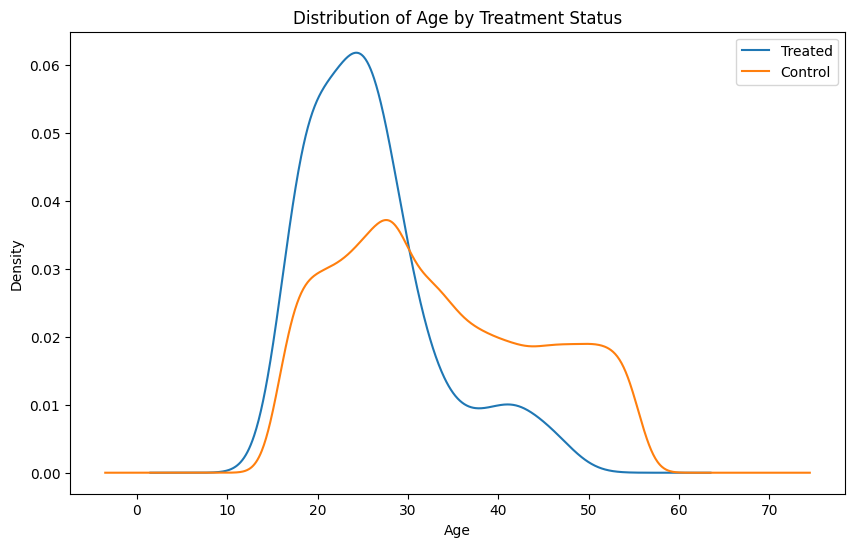

In [6]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)

treated.age.plot.density(ax=ax, label='Treated')
control.age.plot.density(ax=ax, label='Control')
ax.set_xlabel('Age')
ax.set_ylabel('Density')
ax.set_title('Distribution of Age by Treatment Status')
ax.legend()

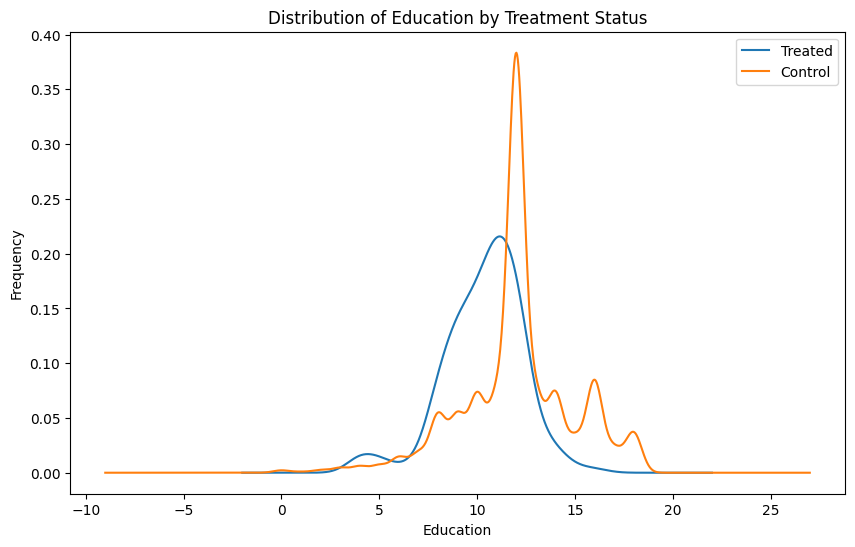

In [7]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)

treated['educ'].plot.density(ax=ax, label='Treated')
control['educ'].plot.density(ax=ax, label='Control')
ax.set_xlabel('Education')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Education by Treatment Status')
ax.legend()

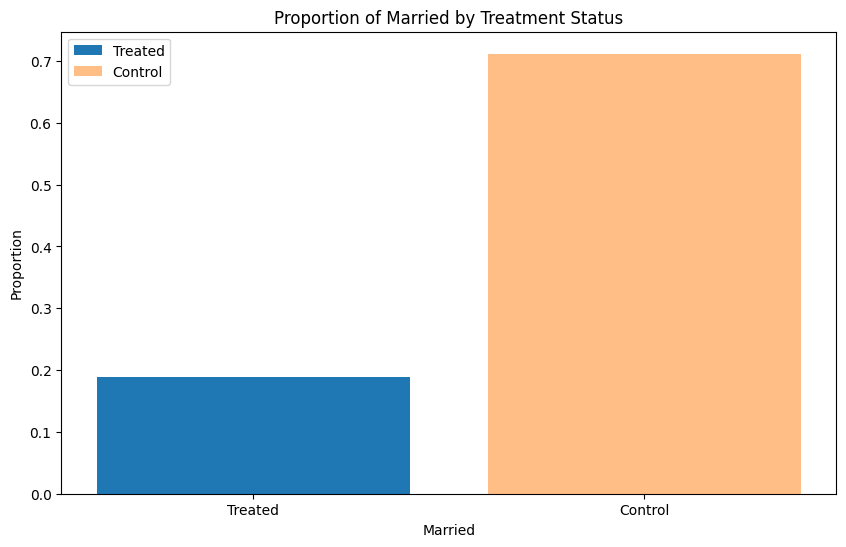

In [8]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)

ax.bar('Treated', treated['married'].value_counts(normalize=True).loc[1], alpha=1, label='Treated')
ax.bar('Control', control['married'].value_counts(normalize=True).loc[1], alpha=0.5, label='Control')
ax.set_xlabel('Married')
ax.set_ylabel('Proportion')
ax.set_title('Proportion of Married by Treatment Status')
ax.legend()

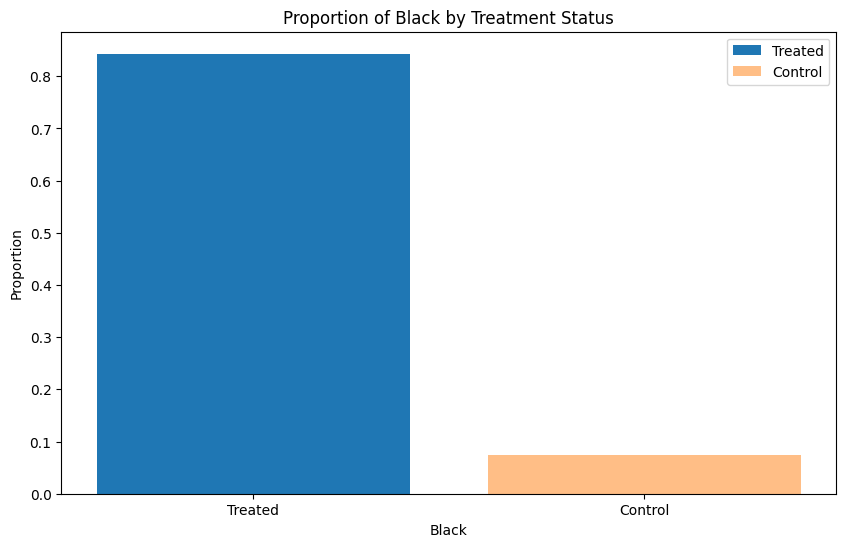

In [9]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)

ax.bar('Treated', treated['black'].value_counts(normalize=True).loc[1], alpha=1, label='Treated')
ax.bar('Control', control['black'].value_counts(normalize=True).loc[1], alpha=0.5, label='Control')
ax.set_xlabel('Black')
ax.set_ylabel('Proportion')
ax.set_title('Proportion of Black by Treatment Status')
ax.legend()

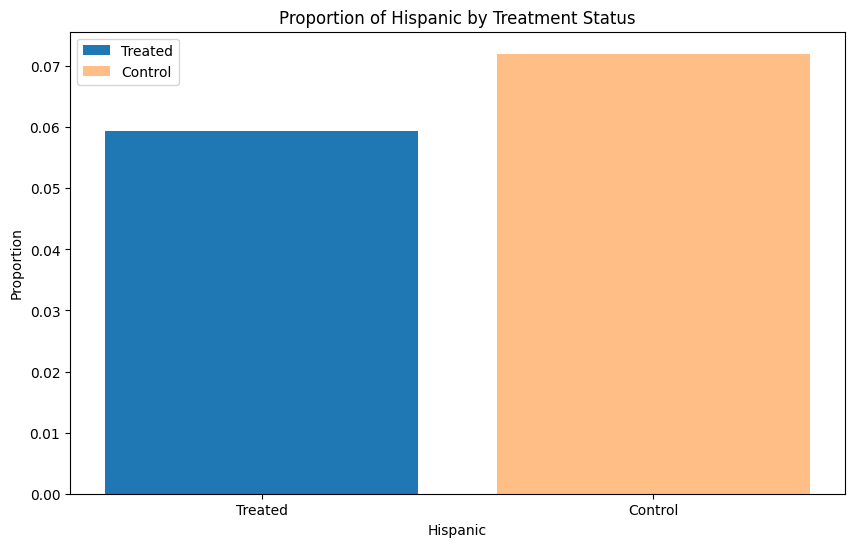

In [10]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)

ax.bar('Treated', treated['hispan'].value_counts(normalize=True).loc[1], alpha=1, label='Treated')
ax.bar('Control', control['hispan'].value_counts(normalize=True).loc[1], alpha=0.5, label='Control')
ax.set_xlabel('Hispanic')
ax.set_ylabel('Proportion')
ax.set_title('Proportion of Hispanic by Treatment Status')
ax.legend()

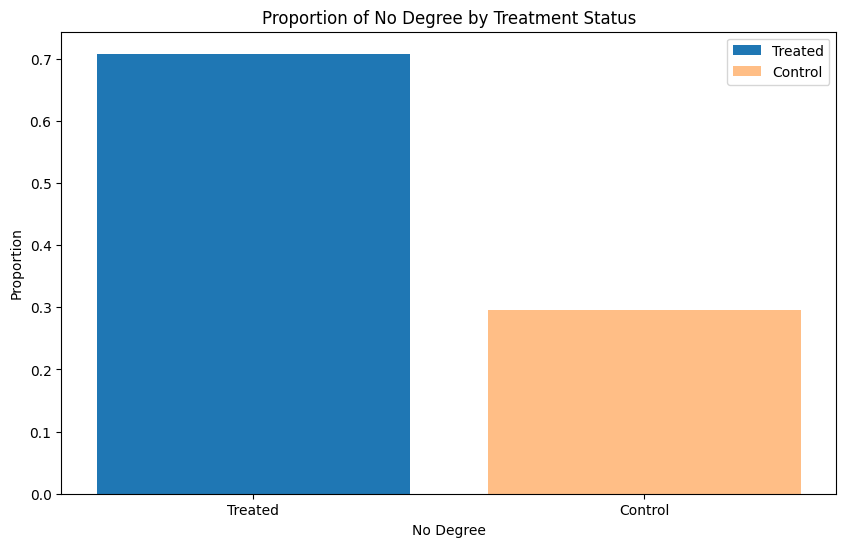

In [11]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)

ax.bar('Treated', treated['nodegree'].value_counts(normalize=True).loc[1], alpha=1, label='Treated')
ax.bar('Control', control['nodegree'].value_counts(normalize=True).loc[1], alpha=0.5, label='Control')
ax.set_xlabel('No Degree')
ax.set_ylabel('Proportion')
ax.set_title('Proportion of No Degree by Treatment Status')
ax.legend()

## Predict the treatment from the covariates

To demonstrate further that there is selection bias we can try to predict the treatment from the covariates...

## Naive Mean Difference Estimate

Below is the estimate for the difference in the means between the treated and control group. We can see that the value is negative, does this mean the job training had a negative effect on earnings? Of course not, we have selection bias which means this estimate is biased and does not represent the ATT.

In [77]:
treated['re78'].mean() - control['re78'].mean()

## OLS Estimates

Refresher on OLS (Scott Cunnigham Chapter)

Why it hasn't recovered the true treatment effect 

- The model might not be properly specificed (could be quadratics or interaction terms)
- Overlap 
- selection bias (how would OLS pick this up)
- OLS doesn't recover the ATT (explain this - what does it recover) 


In [70]:
sm.OLS(df['re78'], sm.add_constant(df.drop(columns=['re78']))).fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   re78   R-squared:                       0.476
Model:                            OLS   Adj. R-squared:                  0.476
Method:                 Least Squares   F-statistic:                     1631.
Date:                Sat, 16 May 2026   Prob (F-statistic):               0.00
Time:                        12:10:26   Log-Likelihood:            -1.6618e+05
No. Observations:               16177   AIC:                         3.324e+05
Df Residuals:                   16167   BIC:                         3.325e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       5735.7310    445.176     12.884      0.000    4863.137    6608.325
treat        699.1318    547.636      1.277      0.202    -374.296    1772.559
age         -101.8551      5.881    -17.320      0.000    -113.382     -90.328
educ         160.1864     28.594      5.602      0.000     104.139     216.234
black       -836.9473    212.826     -3.933      0.000   -1254.109    -419.786
hispan      -218.3184    218.663     -0.998      0.318    -646.923     210.286
married       73.0757    142.409      0.513      0.608    -206.061     352.212
nodegree     372.2376    177.590      2.096      0.036      24.141     720.334
re74           0.2895      0.012     23.953      0.000       0.266       0.313
re75           0.4707      0.012     38.697      0.000       0.447       0.495
==============================================================================
Omnibus:                     1536.524   Durbin-Watson:                   1.965
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             3028.408
Skew:                          -0.632   Prob(JB):                         0.00
Kurtosis:                       4.701   Cond. No.                     2.33e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.33e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

## Propensity Score Matching

One causal inference method that has been proposed in the literature is propensity score matching. Propensity score matching was introduced by Rubin & Rosenbaum (1983). A propensity score is the conditional probability of being assigned to the treatment given the covariates, written as $P(W_{i} = 1 | X_{i})$. Dehejia & Wahba (1999) applied propensity score matching to this dataset and found it was better able to recover the causal effect than was OLS.

The core idea in using propensity scores is they can be used to make the potential outcomes independent of the treatment. As stated above our problem is the control group cannot be used to estimate the outcome of treated group had they not been treated. However, Rubin & Rosenbaum (1983) state that if the potential outcomes, $(Y^{0}, Y^{1}), are conditionally independent of the treatment $W$ given a set of covariates $X_{i}$ then the same conditional independence holds given the probability of $X_{i}$.

$$
E[Y_{i}^{0} | W_{i} = 1] \ne E[Y_{i}^{0} | W_{i} = 0]
$$

$$
Y^{0}, Y^{1} \perp W | X \implies Y^{0}, Y^{1} \perp W | P(W_{i} = 1 | X_{i})
$$

$$
E[Y_{i}^{0} | W_{i} = 0, X_{i}] = E[Y_{i}^{0} | X_{i}]
$$

This means we need to estimate $P(W_{i} = 1 | X_{i})$ for each observation and perform nearest neighbours matching between each treatment unit and the closest $k$ non-treatment units for an estimate of the treatment effect. However, propensity score matching is not the saving grace of causal inference. Some researchers have pointed out paradoxes with the method and advise agaisnt using it (Molak 2023). However, a detailed analysis of the validity of propensity score matching is beyond the scope of this book.

### 1. Estimate propensity scores

In [27]:
lr = LogisticRegression()
lr.fit(df.drop(columns=['treat']), df['treat'])
propensity_scores = lr.predict_proba(df.drop(columns=['treat']))[:, 1]
log_odds_ratio = np.log(propensity_scores / (1 - propensity_scores))

c:\Users\caine\Documents\causal-inference\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


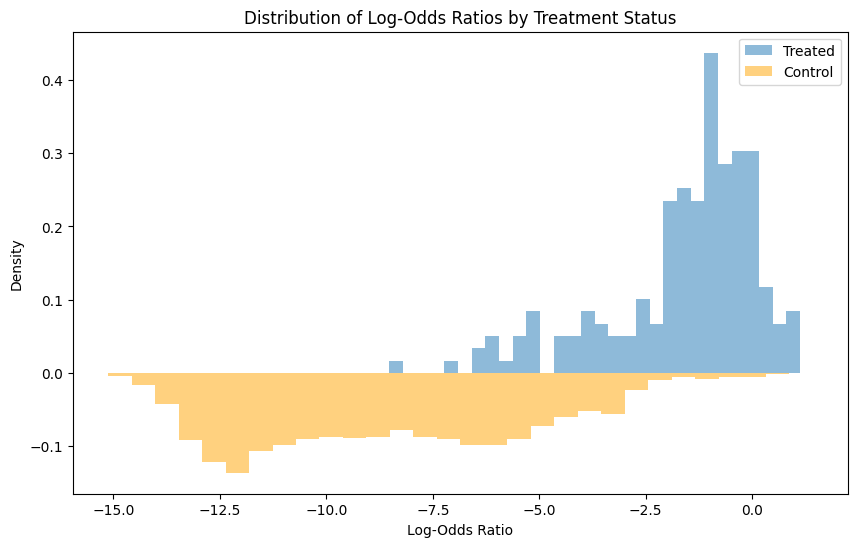

In [74]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)

ax.hist(log_odds_ratio[df['treat'] == 1], alpha=0.5, bins=30, label='Treated', density=True)
control_density, control_bins = np.histogram(log_odds_ratio[df['treat'] == 0], bins=30, density=True)
ax.bar(control_bins[:-1], control_density*-1, alpha=0.5, label='Control', width=np.diff(control_bins), align='edge', color='orange')
ax.set_xlabel('Log-Odds Ratio')
ax.set_ylabel('Density')
ax.set_title('Distribution of Log-Odds Ratios by Treatment Status')
ax.legend()

### 2. Matching

In [91]:
treat_mask = df['treat'].values == 1
treat_pos = np.where(treat_mask)[0]
control_pos = np.where(~treat_mask)[0]

nn = NearestNeighbors(n_neighbors=5, metric='euclidean')
nn.fit(propensity_scores[control_pos].reshape(-1, 1))
distances, indices = nn.kneighbors(propensity_scores[treat_pos].reshape(-1, 1))

# Map kneighbors' relative indices back to original positions
matched_control_pos = control_pos[np.unique(indices.flatten())]

treat_log_odds = log_odds_ratio[treat_pos]
control_log_odds = log_odds_ratio[matched_control_pos]

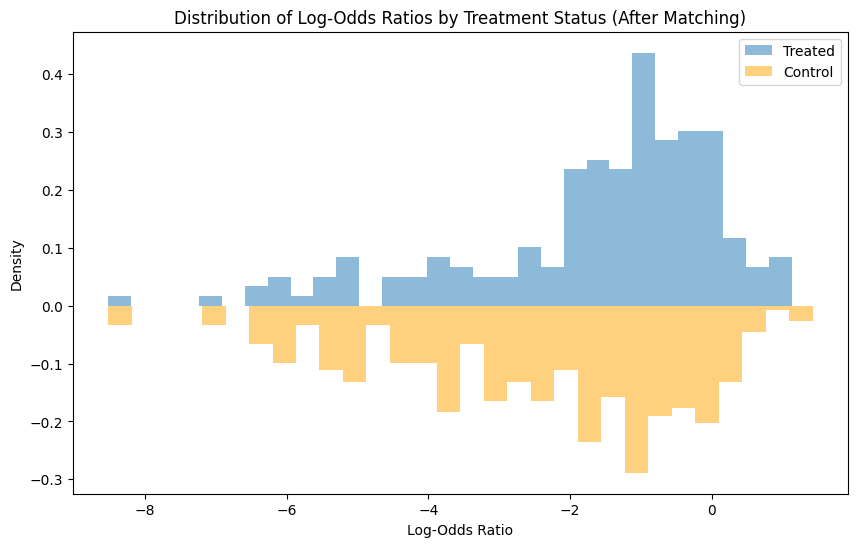

In [92]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)

ax.hist(treat_log_odds, alpha=0.5, bins=30, label='Treated', density=True)
control_density, control_bins = np.histogram(control_log_odds, bins=30, density=True)
ax.bar(control_bins[:-1], control_density*-1, alpha=0.5, label='Control', width=np.diff(control_bins), align='edge', color='orange')
ax.set_xlabel('Log-Odds Ratio')
ax.set_ylabel('Density')
ax.set_title('Distribution of Log-Odds Ratios by Treatment Status (After Matching)')
ax.legend()

In [ ]:
df['re78'].iloc[ma]

0         9930.0460
1         3595.8940
2        24909.4500
3         7506.1460
4          289.7899
            ...    
16172     2757.4380
16173     6895.0720
16174     4221.8650
16175    13671.9300
16176     7979.7240
Name: re78, Length: 16177, dtype: float64

In [94]:
df[df['treat'] == 1]['re78'].mean() - df.iloc[matched_control_pos]['re78'].mean()

np.float64(-0.16572440364143404)

## Doubly Robust Estimator

-- The paper reviewed
-- Why its better


## Summary

## References

Lalonde 1986

Dehejia & Wahba 1999

Rubin & Rosenbaum 1983